In [22]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np
import os
import cdsapi
import xarray as xr
import zipfile
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.utils import resample
from keras.callbacks import EarlyStopping

In [2]:
# iterate through later
df = pd.read_csv(r"datasets\FIRMS\MODIS\fire_archive_M-C61_601999.csv")
df.head(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,-12.4005,141.7752,321.3,2.6,1.5,2019-10-01,26,Terra,MODIS,60,6.03,300.4,32.7,D,0
1,-12.4045,141.7985,319.1,2.5,1.5,2019-10-01,26,Terra,MODIS,52,6.03,300.1,25.3,D,0
2,-14.2813,143.5160,340.4,1.7,1.3,2019-10-01,26,Terra,MODIS,87,6.03,302.8,74.2,D,0
3,-12.4528,141.7104,321.8,2.6,1.5,2019-10-01,26,Terra,MODIS,0,6.03,300.4,42.1,D,0
4,-12.6828,142.0544,335.7,2.4,1.5,2019-10-01,26,Terra,MODIS,81,6.03,302.9,92.9,D,0


In [3]:
df['acq_time'] = df['acq_time'].astype(str).str.zfill(4)
df['datetime'] = pd.to_datetime(df['acq_date'] + ' ' + df['acq_time'], format='%Y-%m-%d %H%M')
df[['acq_date', 'acq_time']].head(5)

,acq_date,acq_time
0,2019-10-01,0026
1,2019-10-01,0026
2,2019-10-01,0026
3,2019-10-01,0026
4,2019-10-01,0026


In [4]:
df['date'] = pd.to_datetime(df['acq_date']).dt.date
df['lat'] = (df['latitude'] // 0.5) * 0.5
df['lon'] = (df['longitude'] // 0.5) * 0.5
df['hour'] = df['acq_time'].astype(str).str.zfill(4).str[:2].astype(int)
df.head(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,datetime,date,lat,lon,hour
0,-12.4005,141.7752,321.3,2.6,1.5,2019-10-01,0026,Terra,MODIS,60,6.03,300.4,32.7,D,0,2019-10-01 00:26:00,2019-10-01,-12.5,141.5,0
1,-12.4045,141.7985,319.1,2.5,1.5,2019-10-01,0026,Terra,MODIS,52,6.03,300.1,25.3,D,0,2019-10-01 00:26:00,2019-10-01,-12.5,141.5,0
2,-14.2813,143.5160,340.4,1.7,1.3,2019-10-01,0026,Terra,MODIS,87,6.03,302.8,74.2,D,0,2019-10-01 00:26:00,2019-10-01,-14.5,143.5,0
3,-12.4528,141.7104,321.8,2.6,1.5,2019-10-01,0026,Terra,MODIS,0,6.03,300.4,42.1,D,0,2019-10-01 00:26:00,2019-10-01,-12.5,141.5,0
4,-12.6828,142.0544,335.7,2.4,1.5,2019-10-01,0026,Terra,MODIS,81,6.03,302.9,92.9,D,0,2019-10-01 00:26:00,2019-10-01,-13.0,142.0,0


In [5]:
df_unique = df.drop_duplicates(subset=['lat', 'lon', 'acq_date'], keep=False)
df_unique = df_unique.reset_index()
print(len(df_unique))
df_unique.head(5)

5555


,index,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,...,version,bright_t31,frp,daynight,type,datetime,date,lat,lon,hour
0,5,-12.0982,142.3159,322.0,2.4,1.5,2019-10-01,0026,Terra,MODIS,...,6.03,296.0,42.2,D,0,2019-10-01 00:26:00,2019-10-01,-12.5,142.0,0
1,31,-15.3763,145.2624,325.5,1.3,1.1,2019-10-01,0027,Terra,MODIS,...,6.03,299.5,25.5,D,0,2019-10-01 00:27:00,2019-10-01,-15.5,145.0,0
2,42,-19.0347,146.6097,310.9,1.0,1.0,2019-10-01,0027,Terra,MODIS,...,6.03,300.4,7.7,D,3,2019-10-01 00:27:00,2019-10-01,-19.5,146.5,0
3,85,-26.7312,145.7333,325.1,1.0,1.0,2019-10-01,0030,Terra,MODIS,...,6.03,310.8,8.7,D,0,2019-10-01 00:30:00,2019-10-01,-27.0,145.5,0
4,89,-30.9695,147.2585,331.6,1.1,1.1,2019-10-01,0031,Terra,MODIS,...,6.03,306.0,22.0,D,0,2019-10-01 00:31:00,2019-10-01,-31.0,147.0,0


In [6]:
grouped = df.groupby(['lat', 'lon'])['acq_date'].unique().reset_index()
grouped.head(5)

,lat,lon,acq_date
0,-44.0,146.5,"[2020-03-18, 2020-03-27]"
1,-43.5,146.5,"[2019-10-23, 2020-01-09, 2020-03-27, 2020-03-28]"
2,-43.5,147.5,[2020-04-09]
3,-43.0,145.0,[2020-03-11]
4,-43.0,146.0,"[2019-12-22, 2020-04-01, 2020-04-09]"


In [7]:
grouped

,lat,lon,acq_date
0,-44.0,146.5,"[2020-03-18, 2020-03-27]"
1,-43.5,146.5,"[2019-10-23, 2020-01-09, 2020-03-27, 2020-03-28]"
2,-43.5,147.5,[2020-04-09]
3,-43.0,145.0,[2020-03-11]
4,-43.0,146.0,"[2019-12-22, 2020-04-01, 2020-04-09]"
...,...,...,...
1731,-11.5,142.5,"[2019-12-02, 2019-12-06, 2019-12-07, 2019-12-0..."
1732,-11.0,142.0,"[2019-10-05, 2019-10-06, 2019-10-08, 2019-10-0..."
1733,-10.5,142.0,"[2019-11-15, 2020-01-27]"
1734,-10.0,142.0,[2020-01-03]


In [8]:
# c = cdsapi.Client()

# def download_and_extract(lat, lon, date):
#     year = str(date.year)
#     month = f"{date.month:02d}"
#     day = f"{date.day:02d}"

#     area = [
#         lat + 0.25, lon - 0.25,
#         lat - 0.25, lon + 0.25
#     ]

#     output_filename = f"./datasets/era5/era5_fire_{year}{month}{day}_{lat:.2f}_{lon:.2f}.zip"
#     extract_path = f"./datasets/era5/era5_fire_{year}{month}{day}_{lat:.2f}_{lon:.2f}/"

#     if os.path.exists(extract_path):
#         print(f"[SKIP] Already exists: {extract_path}")
#         return

#     print(f"[REQUEST] {date.date()} lat: {lat}, lon: {lon}")

#     try:
#         c.retrieve(
#             'reanalysis-era5-single-levels',
#             {
#                 "product_type": "reanalysis",
#                 "variable": [
#                     "10m_u_component_of_wind",
#                     "10m_v_component_of_wind",
#                     "2m_dewpoint_temperature",
#                     "2m_temperature",
#                     "mean_sea_level_pressure",
#                     "sea_surface_temperature",
#                     "significant_height_of_combined_wind_waves_and_swell",
#                     "surface_pressure",
#                     "total_precipitation"
#                 ],
#                 "year": year,
#                 "month": month,
#                 "day": day,
#                 "time": [f"{x:02d}:00" for x in range(24)],
#                 "area": area,
#                 "data_format": "netcdf"
#             },
#             output_filename
#         )

#         with zipfile.ZipFile(output_filename, "r") as zip_ref:
#             zip_ref.extractall(extract_path)

#         print(f"[DONE] Extracted to {extract_path}")

#     except Exception as e:
#         print(f"[ERROR] Failed for {lat}, {lon}, {date.date()}: {e}")

# # Build tasks
# tasks = []
# for idx, row in grouped.iterrows():
#     lat = row['lat']
#     lon = row['lon']
#     dates = pd.to_datetime(row['acq_date'])

#     for date in dates:
#         tasks.append((lat, lon, date))

#     if idx >= 100:
#         break

# # Run in parallel
# MAX_WORKERS = 15  # Try tuning this to match your system
# with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
#     futures = [executor.submit(download_and_extract, lat, lon, date) for lat, lon, date in tasks]

#     for future in as_completed(futures):
#         future.result()  # Propagate exceptions if any


In [9]:
all_weather = []  # list to store each df_weather
base_path = Path('./datasets/era5')

for dir_path in base_path.iterdir():
    if dir_path.is_dir():
        nc_path = dir_path / 'data_stream-oper_stepType-instant.nc'
        if nc_path.exists():
            try:
                # Load dataset
                ds = xr.open_dataset(nc_path, engine='netcdf4')
                
                # Convert Kelvin to Celsius
                ds['t2m'] = ds['t2m'] - 273.15
                ds['d2m'] = ds['d2m'] - 273.15

                # Compute relative humidity
                rh = 100 * (np.exp((17.625 * ds['d2m']) / (243.04 + ds['d2m'])) /
                            np.exp((17.625 * ds['t2m']) / (243.04 + ds['t2m'])))
                ds['humidity'] = rh

                # Compute wind speed
                wind_speed = (ds['u10'] ** 2 + ds['v10'] ** 2) ** 0.5
                ds['wind_speed'] = wind_speed

                # Convert to DataFrame
                df_weather = ds[['t2m', 'd2m', 'msl', 'sst', 'sp', 'humidity', 'wind_speed', 'valid_time']].to_dataframe().reset_index()
                df_weather['date'] = pd.to_datetime(df_weather['valid_time']).dt.date
                df_weather['hour'] = pd.to_datetime(df_weather['valid_time']).dt.hour
                df_weather = df_weather.rename(columns={'latitude': 'lat', 'longitude': 'lon'})

                # Add to list
                all_weather.append(df_weather)
            
            except Exception as e:
                print(f"Error processing {nc_path}: {e}")

# Concatenate all data
df_all_weather = pd.concat(all_weather, ignore_index=True)
len(df_all_weather)

34992

In [10]:
# Mark fire cells
df['fire_label'] = 1
fire_cells = df[['lat', 'lon', 'date', 'fire_label', 'hour']].drop_duplicates()
fire_cells.head(5)

,lat,lon,date,fire_label,hour
0,-12.5,141.5,2019-10-01,1,0
2,-14.5,143.5,2019-10-01,1,0
4,-13.0,142.0,2019-10-01,1,0
5,-12.5,142.0,2019-10-01,1,0
7,-13.5,141.5,2019-10-01,1,0


In [11]:

# Merge with weather
merged = df_all_weather.merge(fire_cells, on=['lat', 'lon', 'date', 'hour'], how='left')
merged['fire_label'] = merged['fire_label'].fillna(0)  # No fire = 0
len(merged)

34992

In [12]:
merged[merged.fire_label == 1].head(5)

,valid_time,lat,lon,t2m,d2m,msl,sst,sp,humidity,wind_speed,number,expver,date,hour,fire_label
4,2019-10-01 00:00:00,-43.0,146.5,7.952057,3.471710,102803.1250,NaN,96971.2500,73.331123,3.984942,0,0001,2019-10-01,0,1.0
247,2019-10-02 03:00:00,-42.5,146.5,18.256378,3.350983,102138.6250,NaN,95552.3125,37.093548,2.930960,0,0001,2019-10-02,3,1.0
436,2019-10-03 00:00:00,-42.5,146.5,19.122101,6.776337,101758.1250,NaN,95212.7500,44.597858,2.132739,0,0001,2019-10-03,0,1.0
472,2019-10-03 04:00:00,-42.5,146.5,23.826813,4.591827,101302.9375,NaN,94824.5000,28.742235,4.294807,0,0001,2019-10-03,4,1.0
688,2019-10-03 04:00:00,-42.5,147.0,23.801422,6.605499,101346.6875,NaN,96354.5000,33.096394,5.006722,0,0001,2019-10-03,4,1.0


In [13]:
features = merged[['t2m', 'd2m', 'msl', 'sp', 'humidity', 'wind_speed']]
labels = merged['fire_label']

In [23]:
combined_data = pd.concat([features, labels], axis=1)

# Separate majority and minority classes
majority_class = combined_data[combined_data['fire_label'] == 0]
minority_class = combined_data[combined_data['fire_label'] == 1]

# Downsample majority class to match minority count
downsampled_majority = resample(
    majority_class,
    replace=False,
    n_samples=len(minority_class),
    random_state=42
)

# Combine and shuffle
balanced_data = pd.concat([downsampled_majority, minority_class]).sample(frac=1, random_state=42)

# Separate again into features and labels
features_balanced = balanced_data.drop('fire_label', axis=1)
labels_balanced = balanced_data['fire_label']

In [25]:
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features_balanced)

labels_balanced = labels_balanced.reset_index(drop=True)

def seq(data, labels, window=7):
    x,y=[],[]
    for i in range(len(data)-window):
        x.append(data[i:i+window])
        y.append(labels[i+window])
    return np.array(x), np.array(y)

x, y = seq(features_scaled, labels_balanced)

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

model = Sequential([
    LSTM(16, input_shape=(x.shape[1], x.shape[2])),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))


early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.fit(x_train, y_train, epochs=20, batch_size=16,
          validation_data=(x_test, y_test),
          class_weight=class_weights, callbacks=[early_stop])

Epoch 1/20


c:\Users\olive\cs5131proj\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5131 - loss: 0.6921 - val_accuracy: 0.5158 - val_loss: 0.6936
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5122 - loss: 0.6914 - val_accuracy: 0.4316 - val_loss: 0.6949
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5410 - loss: 0.6930 - val_accuracy: 0.4526 - val_loss: 0.6968
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5313 - loss: 0.6918 - val_accuracy: 0.4316 - val_loss: 0.6955


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
              precision    recall  f1-score   support

         0.0       0.33      0.05      0.08        44
         1.0       0.53      0.92      0.67        51

    accuracy                           0.52        95
   macro avg       0.43      0.48      0.38        95
weighted avg       0.44      0.52      0.40        95



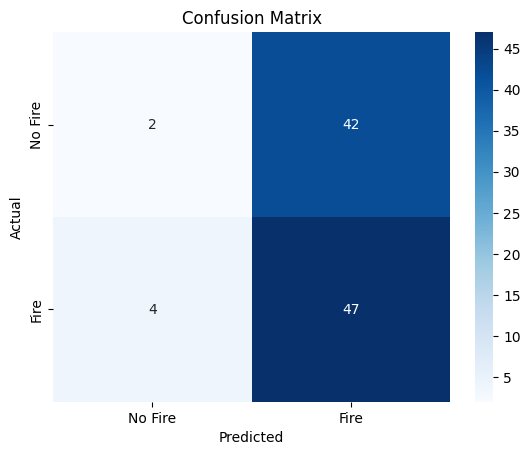

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_prob = model.predict(x_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Fire", "Fire"], yticklabels=["No Fire", "Fire"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
